<a href="https://colab.research.google.com/github/vhugo23/AI-ML-Research-Summer-2025/blob/trying-stuff/LSTM1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving water_consumption_sub.csv to water_consumption_sub.csv


LSTMs are sensitive to scale and noise. Resampling gives consistent intervals, smoothing removes fluctuations, and normalization helps the model learn more effectively.

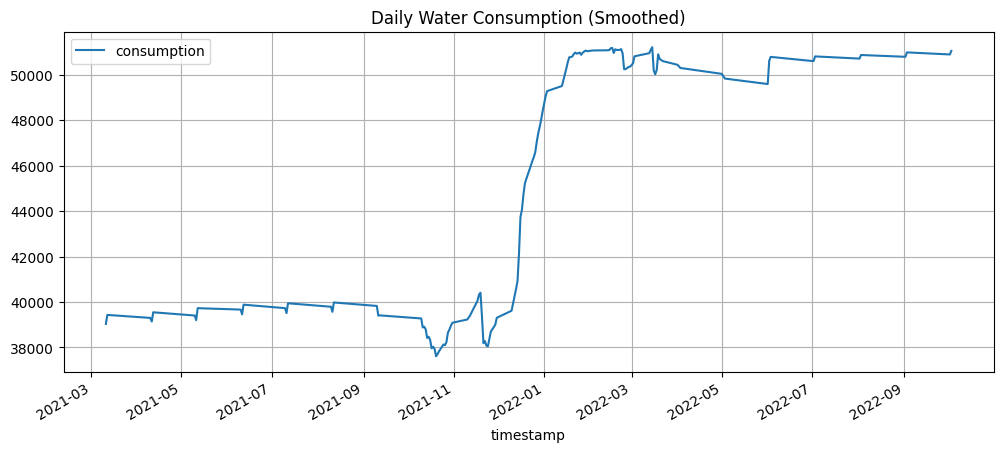

In [9]:
# STEP 1: Preprocess

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load your dataset
df = pd.read_csv("water_consumption_sub.csv")

#Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

#Resample to daily total
df = df[['consumption']].resample('D').sum()

#Remove zeros and apply smoothing
df = df[df['consumption'] > 0]
df['consumption'] = df['consumption'].rolling(window=14, center=True).mean()
df.dropna(inplace=True)

#Plot
df.plot(title='Daily Water Consumption (Smoothed)', figsize=(12,5))
plt.grid(True)
plt.show()


LSTMs expect data in the form: **[Samples, time steps, features]**
We'll use a sliding window (sequence length) to predict the next time point

In [10]:
# STEP 2: Normalize & Frame for Supervised Learning
from sklearn.preprocessing import MinMaxScaler

# Normalize data between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create sequences: 14 days in, predict the next day
def create_sequences(data, seq_length=14):
  X, y = [], []
  for i in range(len(data) - seq_length):
    X.append(data[i:i + seq_length])
    y.append(data[i+ seq_length])
  return np.array(X), np.array(y)

SEQ_LEN = 14
X,y = create_sequences(scaled_data, SEQ_LEN)

print("Shape of X:", X.shape) # (samples, 14, 1)
print("Shape of y:", y.shape)

Shape of X: (144, 14, 1)
Shape of y: (144, 1)


In [13]:
# STEP 3: Train/Test Split
split = int(0.9 * len(X)) #90 % train
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Sequential model
One or more LSTM layers
Dense output layer (1 unit = next consumption value)

In [14]:
# Step 4: Build the LSTM Model
from  tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(SEQ_LEN, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [15]:
# STEP 5: Train the Model
history = model.fit(X_train, y_train, epochs=50, batch_size = 16, validation_split = 0.1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.3392 - val_loss: 0.5127
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2249 - val_loss: 0.2016
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0782 - val_loss: 0.0027
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0237 - val_loss: 0.0229
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0163 - val_loss: 0.0067
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0179 - val_loss: 8.3913e-04
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0127 - val_loss: 0.0095
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0122 - val_loss: 0.0012
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0112 - val_loss: 0.0012
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0092 - val_loss: 0.0055
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0091 - val_loss: 0.0031
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0092 - val_loss: 0.00

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


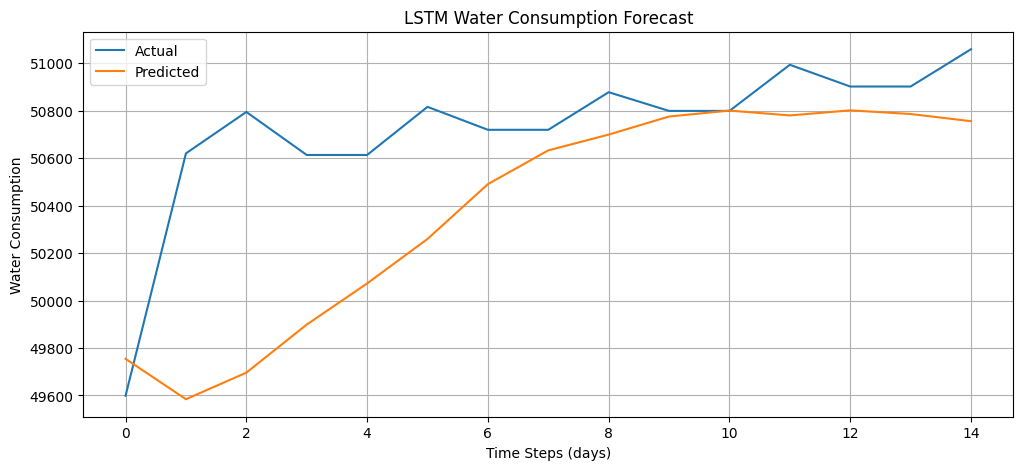

In [17]:
# STEP 6: Evaluate and Plot Predictions
y_pred = model.predict(X_test)

# Inverse transform back to real values
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('LSTM Water Consumption Forecast')
plt.xlabel('Time Steps (days)')
plt.ylabel('Water Consumption')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# OPTIONAL: Calculate MAE & RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 356.94
RMSE: 494.63
